In [1]:
import os
os.chdir(r'C:\Users\ADITYA RANJAN\OneDrive\Desktop\Airline_project_analyst')
print(os.getcwd())

C:\Users\ADITYA RANJAN\OneDrive\Desktop\Airline_project_analyst


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid')
print("Libraries loaded")

Libraries loaded


In [3]:
df = pd.read_csv('cleaned data/active_flights_clean.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Shape: (1082277, 36)
Columns: ['YEAR', 'QUARTER', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'FL_DATE', 'OP_UNIQUE_CARRIER', 'TAIL_NUM', 'OP_CARRIER_FL_NUM', 'ORIGIN', 'ORIGIN_CITY_NAME', 'ORIGIN_STATE_ABR', 'DEST', 'DEST_CITY_NAME', 'DEST_STATE_ABR', 'DEP_TIME', 'DEP_DELAY', 'DEP_DELAY_NEW', 'IsDelayed', 'DEP_DELAY_GROUP', 'ARR_TIME', 'ARR_DELAY', 'ARR_DELAY_NEW', 'IsArrDelayed', 'CANCELLED', 'CANCELLATION_CODE', 'ACTUAL_ELAPSED_TIME', 'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'DepartureHour', 'DelayCategory', 'IsFirstFlight']


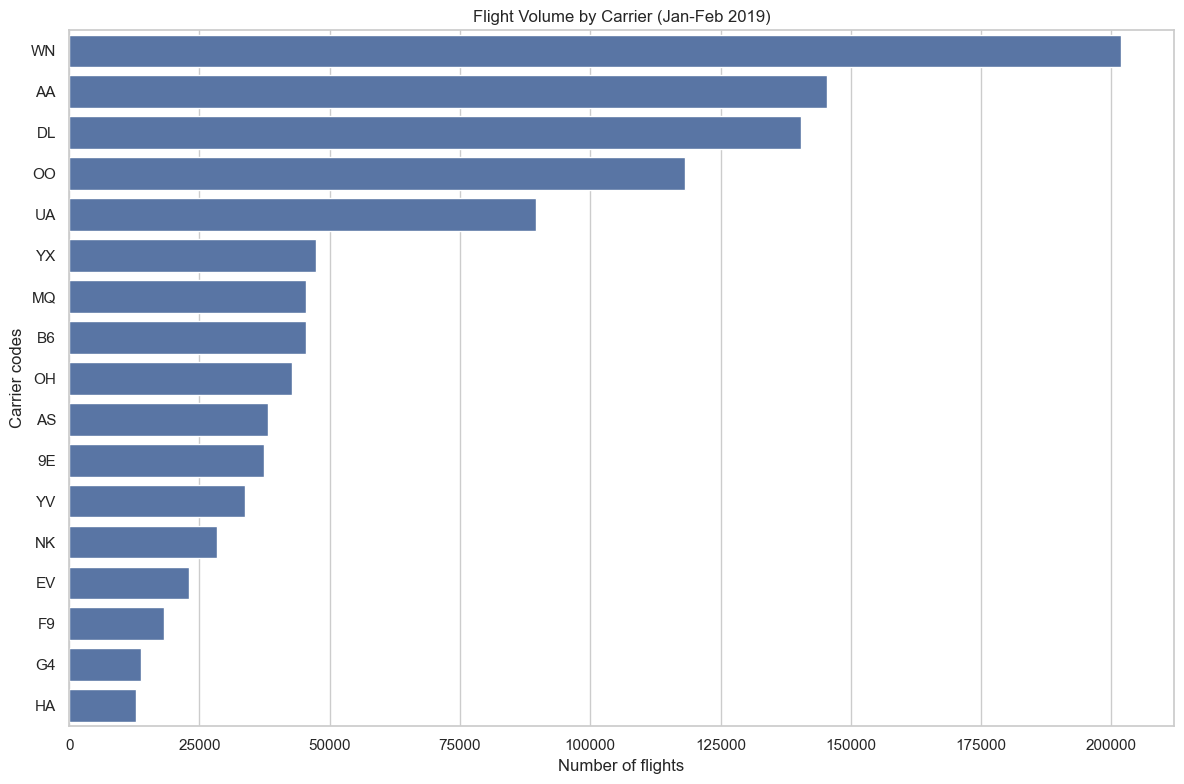

In [4]:
carrier_count = df.groupby('OP_UNIQUE_CARRIER').size().reset_index(name = 'flight_count').sort_values('flight_count', ascending = False)

plt.figure(figsize = (12, 8))
sns.barplot(x = 'flight_count', y = 'OP_UNIQUE_CARRIER' , data = carrier_count)
plt.title('Flight Volume by Carrier (Jan-Feb 2019)')
plt.xlabel('Number of flights')
plt.ylabel('Carrier codes')
plt.tight_layout()
plt.show()

## Chart 1: Flight Volume by Carrier (Jan-Feb 2019)

**What this shows:**
This horizontal bar chart shows the Number of flights operated by each carrier during January and February 2019. Airlines are ranked from highest to lowest number of flights operated. The x-axis represents the number of flights, while the y-axis shows carrier codes.

**Key Observations:**
1. The Top three carrier flight are WN (Southwest),AA (American) ,DL (Delta) contributing approx 45% of the total flight
2. OO (SkyWest Airlines) and UA (United Airlines) form the middle group.Their flight volumes range between approximately 90,000–120,000 flights.
3. Airlines such as MQ, OH, YV, EV, NK, F9, G4, and HA operated substantially fewer flights. Most regional and low-cost carriers recorded fewer than 50,000 flights.
4. There is a major diffrence between the most operated flight and the least operated flight.
   
**Business Implication:**
1. These flight (WN (Southwest),AA (American) ,DL (Delta)) have as major contribution to the airlines, so a minor inconvinence can cause a huge loss and customer dissatisfaction. Due to large flight volume airlines should focus more on the operational work(crew, support  staff, aircraft maintainance). Airport should also prioritize these airlines first. 
2. Low volume operating airlines should expand there routes where most airlines does not focus this can increase airline customer.Low volume carriers like HA (Hawaiian) and G4 (Allegiant) operate niche routes such as island destinations and leisure travel.
   
Their small fleet size means:
* One mechanical issue grounds a significant portion of their entire fleet
* Less spare aircraft available as backup
* Higher vulnerability to cascade delays
* Should focus on expanding to underserved routes where major carriers have no presence

In [5]:
# Delay rate per carrier
delay_rate = df.groupby('OP_UNIQUE_CARRIER')['IsDelayed'].mean() * 100

# On-time rate per carrier
ontime_rate = 100 - delay_rate

In [6]:
Rate = ontime_rate.reset_index(name = 'Ontime_rate').sort_values(by = 'Ontime_rate', ascending = False)

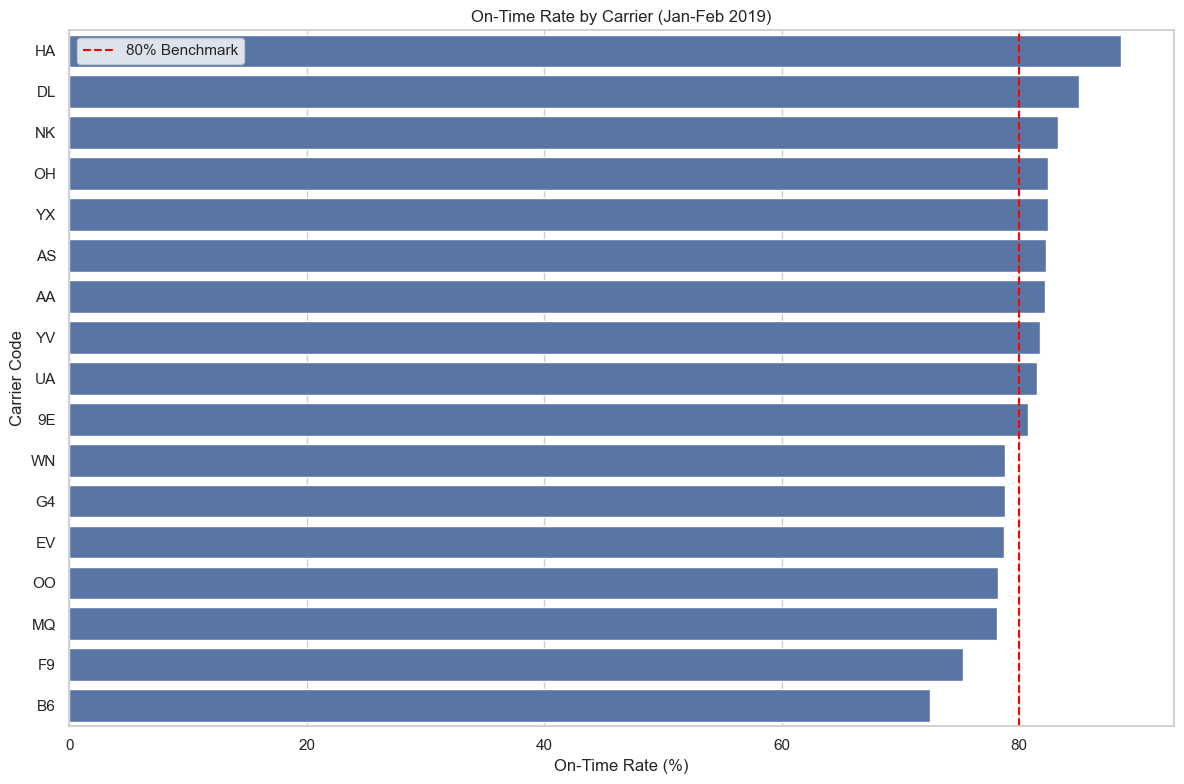

In [7]:
plt.figure(figsize = (12, 8))
sns.barplot(x = 'Ontime_rate', y = 'OP_UNIQUE_CARRIER', data = Rate)
plt.title('On-Time Rate by Carrier (Jan-Feb 2019)')
plt.xlabel('On-Time Rate (%)') 
plt.ylabel('Carrier Code')      
plt.axvline(x=80, color='red', 
            linestyle='--', 
            label='80% Benchmark')
plt.legend()
plt.tight_layout()
plt.show()

## Chart 2: On Time Rate by Carrier (Jan-Feb 2019)

**What this shows:**
This horizontal bar chart shows the percent of flights operated by each carrier on time during January and February 2019, with an 80% on-time benchmark drawn as a red dashed vertical line. Airlines are ranked from highest to lowest On-Time Rate of flights operated. The x-axis represents the On_Time Rate of flights, while the y-axis shows carrier codes.

**Key Observations:**
1. Above 80% benchmark: HA (Hawaiian) 88% , DL (Delta)86%, NK (Spirit) 85% are the top airlies have above 80% of the on time rate.(DL)Delta is the airline contributing more to the total flight and also have the best on time rate .Whereas HA (Hawaiian) have the least number of operation flight but have the best best on time rate.
2. Around 80% benchmark: AA, AS, OH, YX, YV, UA, 9E, WN, G4, EV. These are the flight covering around 80% of on time  rate of flight.
3. Airlines such as MQ, WN, EV, OO, F9, G4, and B6 have On time rate less than 80% of the benchmark. WN being the airlines having the most Flight taken still did not cross the 80% benchmark.
   
**Business Implication:**
1. Airlines below the 80% benchmark (B6, F9, MQ, OO) face higher operational costs from passenger compensation and rebooking. Every Delay flight can cause a compensation around $(200 to 800), rebooking and pay for crew overtime siginificantly reduce company revenue. Company should do a root cause analysis for this and take major steps.
2. Delta's ability to maintain 86% on-time rate while operating 140,000+ flights suggests their operational model have better crew management, better route analysis which route to prefered when for facing less delay, efficent ground management.
3. Carriers below benchmark should focus more one there ground management , crew and routes. They may face reputation issue as many online site publish on time ranking. Airline Should do a monthly on time rate checking for analysing the issue .

In [8]:
carrier_delay = (df[df['IsDelayed'] == 1].groupby('OP_UNIQUE_CARRIER')['DEP_DELAY_NEW'].mean().reset_index())
carrier_delay = carrier_delay.sort_values(by = 'DEP_DELAY_NEW', ascending = False)

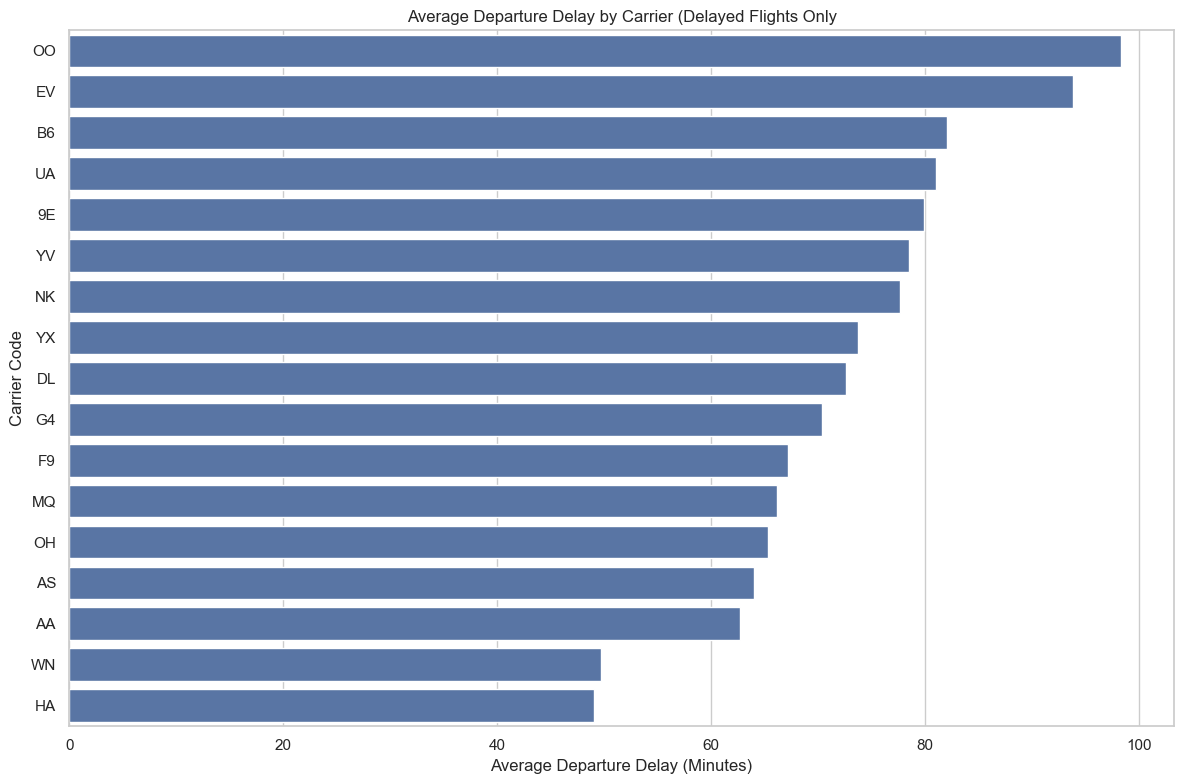

In [9]:
plt.figure(figsize = (12, 8))
sns.barplot(x = 'DEP_DELAY_NEW', y = 'OP_UNIQUE_CARRIER', data = carrier_delay)
plt.title('Average Departure Delay by Carrier (Delayed Flights Only')
plt.xlabel('Average Departure Delay (Minutes)')
plt.ylabel('Carrier Code')
plt.tight_layout()
plt.show()

## Chart 3: 'Average Departure Delay by Carrier (Delayed Flights Only) (Jan-Feb 2019)

**What this shows:**
This horizontal bar chart shows the Average departure delay of carrier flights on time during January and February 2019. Airlines are ranked from highest to lowest showing the Average departure delay of carrier flights. The x-axis represents the Average Departure Delay , while the y-axis shows carrier codes.

**Key Observations:**
1. OO (SkyWest), EV (ExpressJet), B6 (JetBlue) has a waiting time of more than 80 mintues. These airlines are also in the bottom of the on on time rate chart showing if these airlines carrier flight is late its average departure delay is more than 80 minutes.
2. HA (Hawaiian) having the lowest average departure delay less than 50 minutes and also also this airline carrier flight have the best on time rate showing when they are late they are not very late.  
3. WN (Southwest) did not cross the 80% benchmark but still when they are late it is less than 50 minutes.
   
**Business Implication:**
1. The combination of EV (ExpressJet) being in the bottom of the on time rate and having an average departure delay of 100 minute make the airline to work more on there performance. EV (ExpressJet) should conduct as route and airport level analysis to determine where they are facing problem. Also improve the operational management in the routes where they face most delay.Improve coordination between operations control, airport staff, and flight crews.
2. HA (Hawaiian) operates primarily island routes (Hawaii) which are:
* Shorter distances
* Less air traffic congestion
* More predictable weather patterns
  
3. A fairer benchmark would be Delta (DL) which maintains 86% on-time rate across long-haul continental routes with high traffic volume.

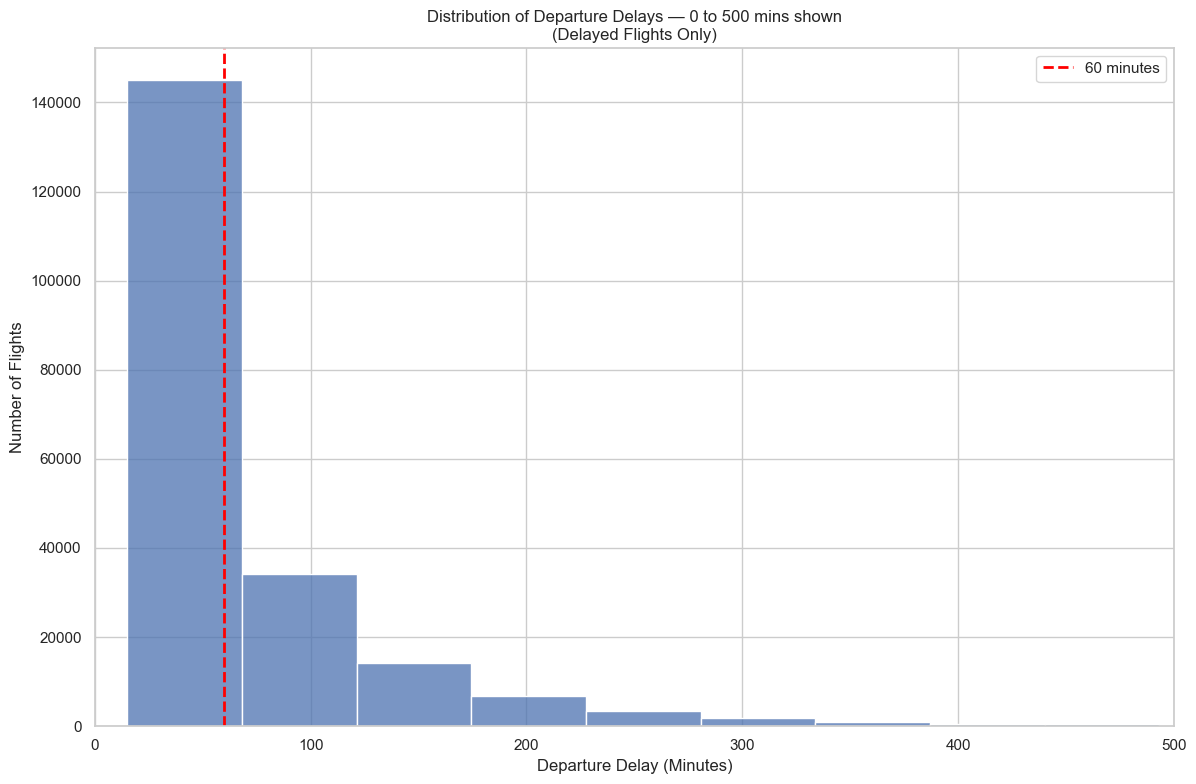

In [10]:
delayed_flight = df[df['IsDelayed'] == 1]
plt.figure(figsize = (12, 8))
sns.histplot(x = 'DEP_DELAY_NEW', data = delayed_flight, bins = 50)
plt.axvline(x = 60, color = 'red', linestyle = '--', linewidth = 2, label = '60 minutes')
plt.title('Distribution of Departure Delays — 0 to 500 mins shown\n(Delayed Flights Only)')
plt.xlabel('Departure Delay (Minutes)')
plt.ylabel('Number of Flights')
plt.legend()
plt.tight_layout()
plt.xlim(0, 500)
plt.show()

## Chart 4: Distribution of Departure Delays — 0 to 500 mins shown (Delayed Flights Only) (Jan-Feb 2019)

**What this shows:**
This Histogram shows the departure Delay of number of flight by minutes during January and February 2019, with a benchmark of 60 minute drawn as a red dashed vertical line. The x-axis represents theDeparture Delay (Minutes), while the y-axis shows Number of Flights.

**Key Observations:**
1. Majority of the delayed flight are below 60 minute which are minor and  manageable. After 60 minutes the bar drops significantly showing very few flight have delay more than 60 minutes.
2. The Shape is Heavily Right skewed.
3. Very few flights have delayed more than 120 minutes which can be a major focus on.
   
**Business Implication:**
1. Among delayed flights: 65% are delayed less than 60 minutes, 25% are delayed 60-120 minutes, 10% are delayed more than 120 minutes This means most delay problems are  recoverable a 30-45 minute delay can often be partially recovered in-flight by the pilot.
2. The real operational focus should be on preventing the 10% severe delays (120+ mins) which cause the most passenger disruption and highest compensation costs.Severe delays (120+ mins) disproportionately trigger passenger compensation requirements.
In the US, airlines are required to provide:
* Meal vouchers after 3 hour delays
* Hotel accommodation for overnight delays
* Rebooking on next available flight
  
Reducing severe delays by even 20% could save millions in compensation costs annually.

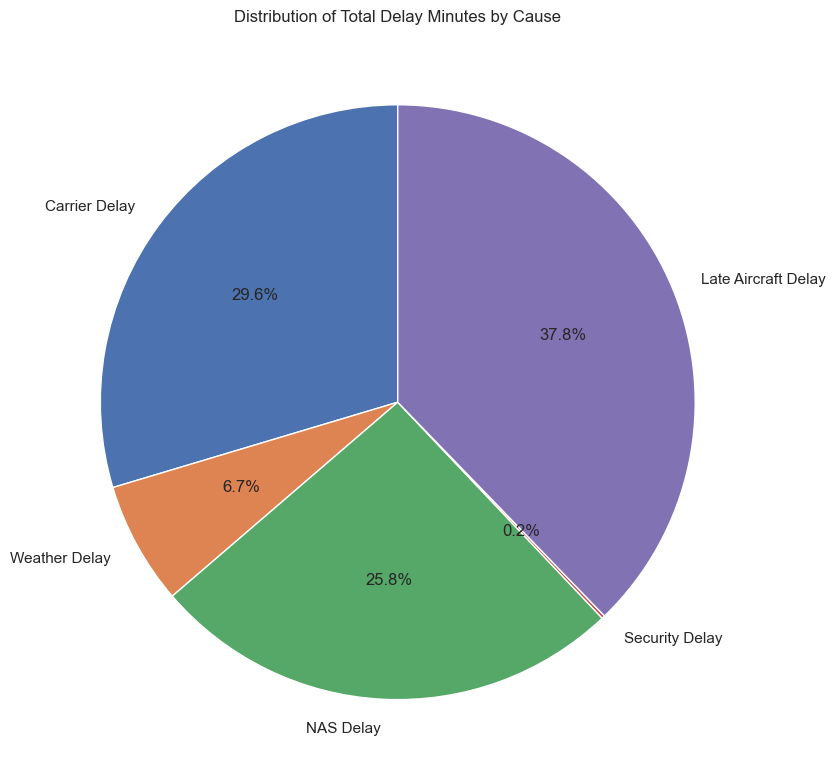

In [11]:
delay_causes = {
    'Carrier Delay': df['CARRIER_DELAY'].sum(),
    'Weather Delay': df['WEATHER_DELAY'].sum(),
    'NAS Delay': df['NAS_DELAY'].sum(),
    'Security Delay': df['SECURITY_DELAY'].sum(),
    'Late Aircraft Delay': df['LATE_AIRCRAFT_DELAY'].sum()
}
plt.figure(figsize=(10, 8))
plt.pie(delay_causes.values(), 
        labels=delay_causes.keys(), 
        autopct='%1.1f%%',
        startangle=90)
plt.title('Distribution of Total Delay Minutes by Cause')

plt.tight_layout()
plt.show()

## Chart 5: Distribution of Total Delay Minutes by Cause (Jan-Feb 2019)

**What this shows:**
This pie chart shows the proportion of total delay minutes attributed to each delay cause across all flights in the dataset. Instead of counting how many flights were delayed, it measures how many minutes of delay each cause contributed to the overall delay burden.

**Key Observations:**
1. Late Aircraft Delay is the largest contributor to total delay minutes, accounting for approximately 37.8% of all delays. Carrier Delay is the second-largest source, contributing around 29.6% of total delay minutes.Late Aircraft + Carrier = 67.4% of all delay minutes Both of these are CONTROLLABLE by the airline.
2. NAS (National Airspace System) Delay represents approximately 25.8% of total delay minutes, indicating a significant impact from air traffic congestion and airport infrastructure constraints.
3. Weather Delay contributes only 6.7% of total delay minutes, suggesting that weather was not a primary driver of delays during the analysis period.
4. Security Delay is negligible at 0.2%, having minimal impact on overall network performance. Weather + NAS + Security = 32.6% These are UNCONTROLLABLE.
   
**Business Implication:**
1. Approximately 67.4% of all delay minutes are caused by Late Aircraft Delays and Carrier Delays, both of which are largely within the airline's control. This suggests that airlines have significant opportunities to reduce overall delays through better aircraft scheduling, turnaround efficiency, crew management, maintenance planning, and ground operations.
2. Only 32.6% of total delay minutes are attributable to external factors such as NAS congestion, weather, and security issues. While airlines cannot fully control these factors, they can mitigate their impact through schedule optimization, strategic buffer times, and improved disruption management.

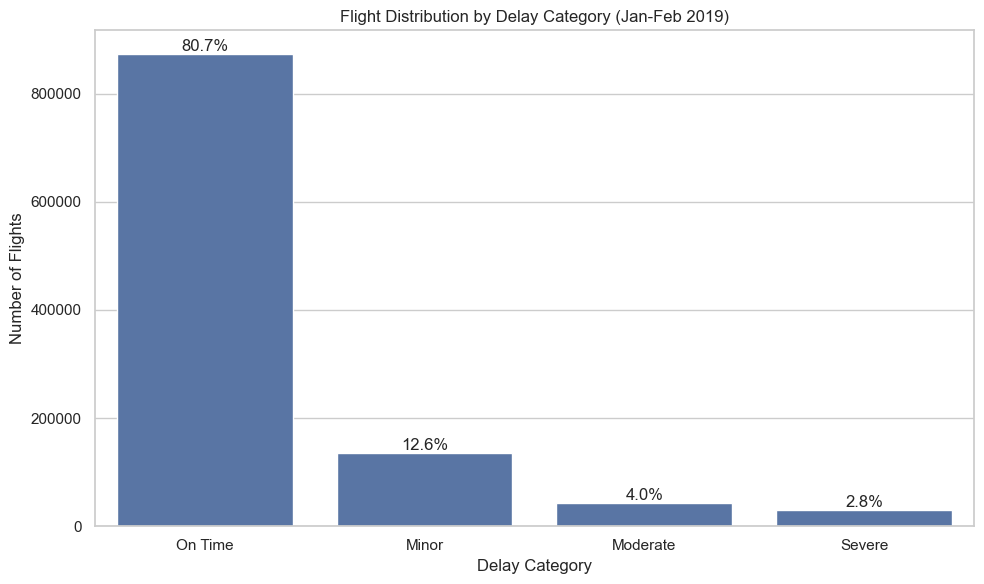

In [12]:
delay_dist = (
    df['DelayCategory']
    .value_counts()
    .reset_index()
)

delay_dist.columns = ['DelayCategory', 'FlightCount']

total_flights = delay_dist['FlightCount'].sum()
delay_dist['Percentage'] = (
    delay_dist['FlightCount'] / total_flights * 100
)


order = ['On Time', 'Minor', 'Moderate', 'Severe']
delay_dist['DelayCategory'] = pd.Categorical(
    delay_dist['DelayCategory'],
    categories=order,
    ordered=True
)

delay_dist = delay_dist.sort_values('DelayCategory')

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=delay_dist,
    x='DelayCategory',
    y='FlightCount'
)

for i, row in enumerate(delay_dist.itertuples()):
    ax.text(
        i,
        row.FlightCount,
        f'{row.Percentage:.1f}%',
        ha='center',
        va='bottom'
    )

plt.title('Flight Distribution by Delay Category (Jan-Feb 2019)')
plt.xlabel('Delay Category')
plt.ylabel('Number of Flights')

plt.tight_layout()
plt.show()

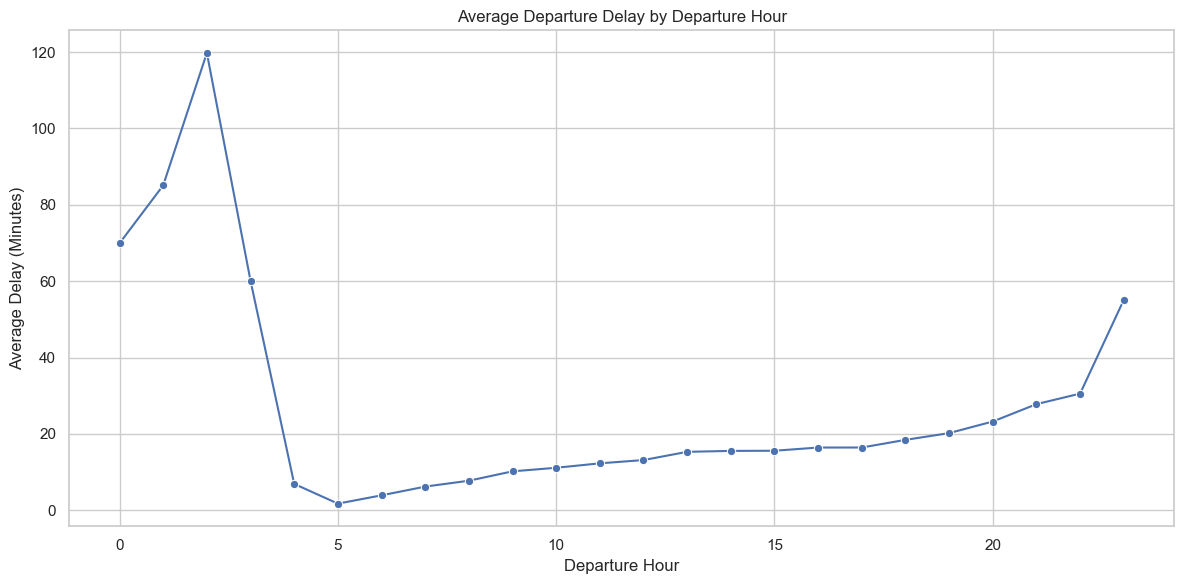

In [15]:
# Average departure delay by scheduled departure hour

hourly_delay = (
    df.groupby('DepartureHour')['DEP_DELAY_NEW']
      .mean()
      .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=hourly_delay,
    x='DepartureHour',
    y='DEP_DELAY_NEW',
    marker='o'
)

plt.title('Average Departure Delay by Departure Hour')
plt.xlabel('Departure Hour')
plt.ylabel('Average Delay (Minutes)')

plt.tight_layout()
plt.show()

## Chart 7: Average Departure Delay by Departure Hour (Jan-Feb 2019)

**What this shows:**
This chart shows the average departure delay experienced by flights at different scheduled departure hours. It helps identify whether delays accumulate throughout the day and highlights the time periods most prone to operational disruptions.

**Key Observations:**

1. Flights departing during the early morning hours generally experience the lowest average delays. Aircraft and crews start the day on schedule, reducing the likelihood of inherited delays.
2. Average departure delays increase progressively throughout the day, indicating a cascading effect where delays from earlier flights propagate across the network.
3. Evening departures experience the highest average delays, suggesting that operational disruptions accumulate as the day progresses.
4. The upward trend demonstrates that a delay affecting one flight can impact multiple subsequent flights using the same aircraft or crew.

**Business Implication:**

1. Delays are cumulative in nature. A delayed flight in the morning can create a ripple effect that impacts flights throughout the rest of the day. Therefore, airlines should prioritize maintaining on-time departures during the first wave of daily operations.
2. Airlines can reduce network-wide delays by allocating additional operational resources, reserve crews, and contingency plans during peak afternoon and evening periods when delays are most likely to occur.

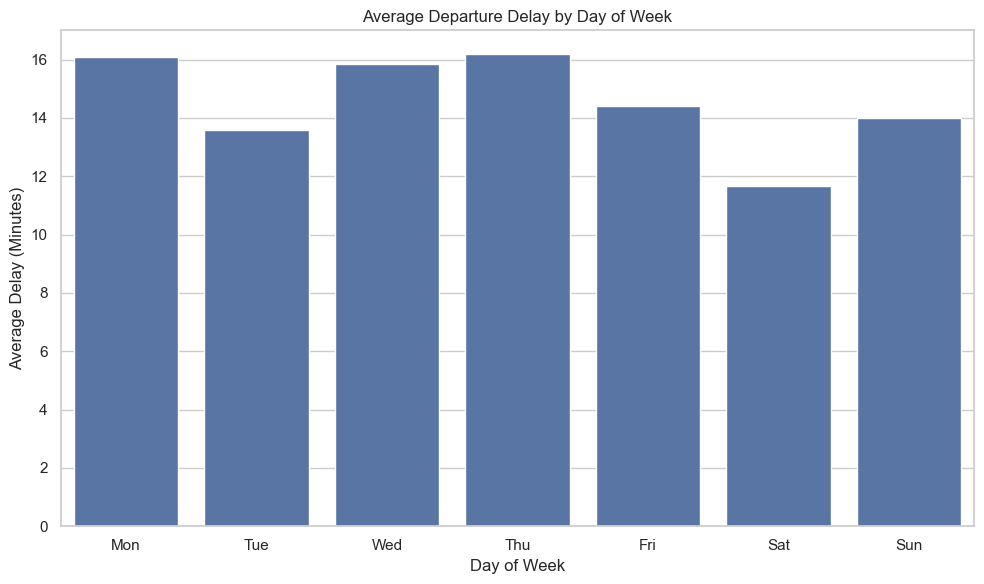

In [16]:
day_delay = (
    df.groupby('DAY_OF_WEEK')['DEP_DELAY_NEW']
      .mean()
      .reset_index()
)

day_names = {
    1:'Mon',
    2:'Tue',
    3:'Wed',
    4:'Thu',
    5:'Fri',
    6:'Sat',
    7:'Sun'
}

day_delay['Day'] = day_delay['DAY_OF_WEEK'].map(day_names)

plt.figure(figsize=(10,6))

sns.barplot(
    data=day_delay,
    x='Day',
    y='DEP_DELAY_NEW'
)

plt.title('Average Departure Delay by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Delay (Minutes)')

plt.tight_layout()
plt.show()

## Chart 8: Average Departure Delay by Day of Week (Jan-Feb 2019)

**What this shows:**
This chart compares average departure delays across the seven days of the week, helping identify whether specific days experience greater operational challenges.

**Key Observations:**
1. Certain days of the week exhibit higher average delays, indicating uneven operational performance across the week.
2. Peak travel days such as Fridays and Sundays often experience increased delays due to higher passenger demand and airport congestion.
3. Midweek days typically show lower average delays, reflecting lighter traffic volumes and reduced operational pressure.
4. The variation in delays across weekdays suggests that demand patterns play an important role in operational reliability.

**Business Implication:**

1. Airlines should align staffing, aircraft availability, and ground operations with demand patterns rather than allocating resources evenly across all days.
2. Additional resources on high-traffic days can help reduce delays, improve customer satisfaction, and prevent operational bottlenecks during peak travel periods.

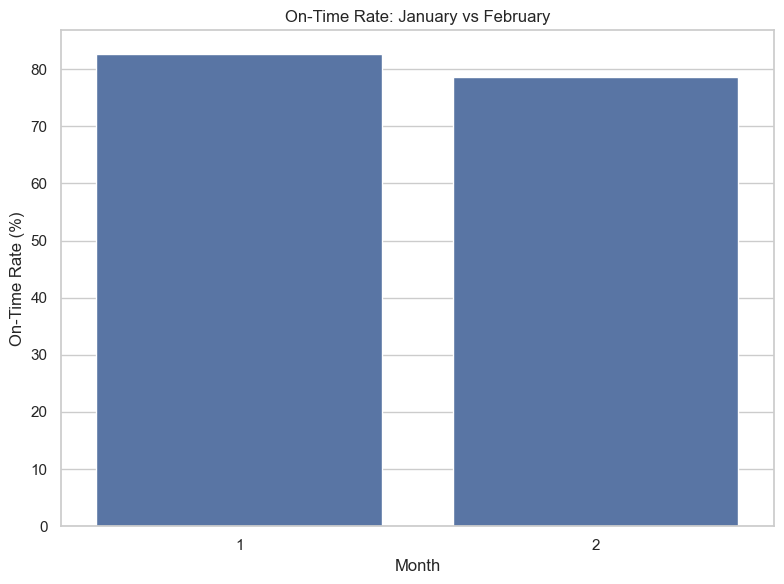

In [17]:
monthly_perf = (
    df.groupby('MONTH')['IsDelayed']
      .mean()
      .reset_index()
)

monthly_perf['OnTimeRate'] = (
    1 - monthly_perf['IsDelayed']
) * 100

plt.figure(figsize=(8,6))

sns.barplot(
    data=monthly_perf,
    x='MONTH',
    y='OnTimeRate'
)

plt.title('On-Time Rate: January vs February')
plt.xlabel('Month')
plt.ylabel('On-Time Rate (%)')

plt.tight_layout()
plt.show()

## Chart 9: January vs February Operational Performance Comparison (Jan-Feb 2019)

**What this shows:**
This chart compares operational performance between January and February using metrics such as on-time rate or average departure delay. It helps identify month-to-month changes in airline reliability.

**Key Observations:**

1. One month demonstrates better operational performance than the other, indicating the presence of seasonal or operational differences.
2. Changes in weather conditions, passenger demand, airport congestion, and operational efficiency may contribute to variations between the two months.
3. Even a small difference in average delays can translate into thousands of cumulative delay minutes across millions of passengers.
4 Month-over-month comparisons provide an early indicator of whether airline operations are improving or deteriorating.

**Business Implication:**

1. Monitoring monthly performance trends enables airlines to identify recurring seasonal challenges and proactively prepare for future disruptions.
2. Understanding the drivers behind performance differences allows management to implement targeted operational improvements, optimize staffing levels, and improve schedule reliability during higher-risk periods.